# Матричные разложения: демо-тетрадка

Тетрадка-компаньон к лекции. Идея всей темы в одной строчке:

$$X = A \cdot B$$

слева — матрица с **непонятной** структурой, справа — произведение матриц с **понятной** (треугольной, ортогональной, диагональной). Понятная структура = быстрые алгоритмы и геометрическая интерпретация.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.figsize"] = (5, 5)

## 1. Зоопарк структурных матриц

| Тип | Условие |
|---|---|
| Верхнетреугольная | $a_{ij} = 0$ при $i > j$ |
| Нижнетреугольная | $a_{ij} = 0$ при $i < j$ |
| Симметричная | $A^\top = A$ |
| Кососимметричная | $A^\top = -A$ |
| Ортогональная | $A^\top A = A A^\top = I$, то есть $A^{-1} = A^\top$ |
| Диагональная | $A = \mathrm{diag}(\lambda_1, \dots, \lambda_n)$ |
| Положительно определённая | $\forall v \ne 0:\ v^\top A v > 0$ |

In [2]:
A = np.arange(1, 17).reshape(4, 4).astype(float)

print("Верхнетреугольная:\n", np.triu(A))
print("\nНижнетреугольная:\n", np.tril(A))
print("\nСимметричная:\n", (A + A.T) / 2)
print("\nКососимметричная:\n", (A - A.T) / 2)
print("\nДиагональная:\n", np.diag([1., 2., 3., 4.]))

Верхнетреугольная:
 [[ 1.  2.  3.  4.]
 [ 0.  6.  7.  8.]
 [ 0.  0. 11. 12.]
 [ 0.  0.  0. 16.]]

Нижнетреугольная:
 [[ 1.  0.  0.  0.]
 [ 5.  6.  0.  0.]
 [ 9. 10. 11.  0.]
 [13. 14. 15. 16.]]

Симметричная:
 [[ 1.   3.5  6.   8.5]
 [ 3.5  6.   8.5 11. ]
 [ 6.   8.5 11.  13.5]
 [ 8.5 11.  13.5 16. ]]

Кососимметричная:
 [[ 0.  -1.5 -3.  -4.5]
 [ 1.5  0.  -1.5 -3. ]
 [ 3.   1.5  0.  -1.5]
 [ 4.5  3.   1.5  0. ]]

Диагональная:
 [[1. 0. 0. 0.]
 [0. 2. 0. 0.]
 [0. 0. 3. 0.]
 [0. 0. 0. 4.]]


In [ ]:
# Положительная определённость удобно проверяется через собственные числа:
# для симметричной A условие "v.T @ A @ v > 0 для всех v != 0"
# эквивалентно "все собственные числа > 0"

S = np.array([[2., 1.],
              [1., 2.]])
print("собственные числа:", np.linalg.eigvalsh(S))

rng = np.random.default_rng(7)
checks = [v @ S @ v > 0 for v in rng.normal(size=(1000, 2))]
print("v.T @ S @ v > 0 на 1000 случайных v:", all(checks))

собственные числа: [1. 3.]
v.T @ S @ v > 0 на 1000 случайных v: True


### Пример из статистики: ковариационная матрица

$$\Sigma = \begin{pmatrix} \mathrm{Var}(X) & \mathrm{Cov}(X, Y) \\ \mathrm{Cov}(X, Y) & \mathrm{Var}(Y) \end{pmatrix}, \qquad \mathrm{Var}(v_1 X + v_2 Y) = v^\top \Sigma\, v \ge 0.$$

Она всегда симметрична и положительно **полу**определена. Строго определённой ($> 0$) она будет, только если между $X$ и $Y$ нет точной линейной связи — иначе найдётся комбинация с нулевой дисперсией. Ниже оба случая.

In [ ]:
rng = np.random.default_rng(0)
X = rng.normal(size=100_000)

# невырожденный случай: Y — не линейная функция X
Y = 0.5 * X + rng.normal(size=X.size)
Sigma = np.cov(X, Y)
print("невырожденный случай, собственные числа:", np.linalg.eigvalsh(Sigma))

# вырожденный случай: Y = 2X, комбинация 2X - Y имеет нулевую дисперсию
Y_deg = 2 * X
Sigma_deg = np.cov(X, Y_deg)
print("Y = 2X, собственные числа:", np.linalg.eigvalsh(Sigma_deg))

v = np.array([2., -1.])
print("Var(2X - Y) = v.T @ Sigma @ v =", v @ Sigma_deg @ v)

невырожденный случай, собственные числа: [0.61  1.646]
Y = 2X, собственные числа: [-0.     5.001]
Var(2X - Y) = v.T @ Sigma @ v = 0.0


## 2. Ортогональная инвариантность

Если $Q$ ортогональна ($Q^\top Q = I$), то

$$\|Qx\|_2^2 = x^\top Q^\top Q\, x = x^\top x = \|x\|_2^2$$

— умножение на $Q$ сохраняет длины, расстояния и углы. Произведение двух ортогональных матриц снова ортогонально:

$$(VQ)^\top VQ = Q^\top \underbrace{V^\top V}_{I} Q = Q^\top Q = I.$$

In [5]:
rng = np.random.default_rng(1)
Q, _ = np.linalg.qr(rng.normal(size=(3, 3)))   # случайная ортогональная матрица

x = np.array([1., 2., 3.])
y = np.array([-2., 0.5, 1.])

print("Q.T @ Q =\n", Q.T @ Q)
print("\n||x|| =", np.linalg.norm(x), " ||Qx|| =", np.linalg.norm(Q @ x))

cos = lambda a, b: a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
print("cos(x, y) =", cos(x, y), " cos(Qx, Qy) =", cos(Q @ x, Q @ y))

V, _ = np.linalg.qr(rng.normal(size=(3, 3)))
print("\n(VQ).T @ (VQ) =\n", (V @ Q).T @ (V @ Q))

Q.T @ Q =
 [[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

||x|| = 3.7416573867739413  ||Qx|| = 3.741657386773942
cos(x, y) = 0.23328473740792174  cos(Qx, Qy) = 0.23328473740792197

(VQ).T @ (VQ) =
 [[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


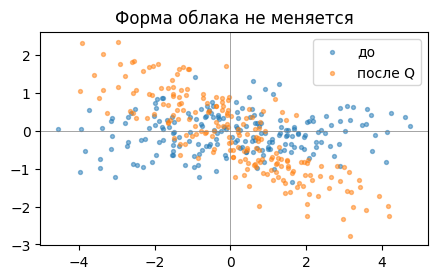

In [6]:
# картинка: ортогональное преобразование крутит облако точек, не меняя формы
rng = np.random.default_rng(2)
cloud = rng.normal(size=(200, 2)) @ np.diag([2.0, 0.5])

phi = np.pi / 6
Q2 = np.array([[np.cos(phi), np.sin(phi)],
               [-np.sin(phi), np.cos(phi)]])
rotated = cloud @ Q2.T

fig, ax = plt.subplots()
ax.scatter(*cloud.T, s=8, alpha=0.5, label="до")
ax.scatter(*rotated.T, s=8, alpha=0.5, label="после Q")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal"); ax.legend(); ax.set_title("Форма облака не меняется")
plt.show()

## 3. Отражения

Простейшее отражение — относительно оси $x_1$: $(v_1, v_2) \mapsto (v_1, -v_2)$,

$$A = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}.$$

Отражение — это матрица, для которой $A^\top = A$ и $A^{-1} = A$ (а значит, $A^\top A = A^2 = I$ — она ещё и ортогональна).

**Упражнение (а):** отражение относительно прямой $x_2 = x_1$ — это $A = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$: оно просто меняет координаты местами.

In [ ]:
A_swap = np.array([[0., 1.],
                   [1., 0.]])

print("A @ (2, 1) =", A_swap @ np.array([2., 1.]))   # ожидаем (1, 2)

A @ (2, 1) = [1. 2.]


**Упражнение (б):** отражение относительно прямой $x_2 = \tfrac{1}{2} x_1$.

Первый столбец матрицы — образ $e_1 = (1, 0)$. Ищем проекцию $(1,0)$ на прямую $\{(2z, z)\}$:

$$(2z - 1)^2 + (z - 0)^2 \to \min_z \quad\Rightarrow\quad 4z - 2 + z = 0 \quad\Rightarrow\quad z = \tfrac{2}{5},$$

точка проекции $\left(\tfrac{4}{5}, \tfrac{2}{5}\right)$. Отражение лежит «по ту сторону» на том же расстоянии:

$$\begin{pmatrix}1\\0\end{pmatrix} + \begin{pmatrix}x\\y\end{pmatrix} = 2\begin{pmatrix}4/5\\2/5\end{pmatrix} \quad\Rightarrow\quad \begin{pmatrix}x\\y\end{pmatrix} = \begin{pmatrix}3/5\\4/5\end{pmatrix}.$$

Общая формула через проекцию $\mathrm{proj}_v x = \dfrac{v v^\top}{v^\top v}\, x$: из $x + Hx = 2\,\mathrm{proj}_v x$ получаем

$$H = 2\,\frac{v v^\top}{v^\top v} - I \qquad \text{— отражение относительно прямой } \mathrm{span}(v).$$

In [8]:
v = np.array([2., 1.])                    # направляющий вектор прямой x2 = x1/2
H = 2 * np.outer(v, v) / (v @ v) - np.eye(2)
print("H =\n", H)                        # первый столбец (3/5, 4/5) — как в лекции

e1 = np.array([1., 0.])
proj = np.outer(v, v) / (v @ v) @ e1
print("\nпроекция e1 на прямую:", proj)  # (4/5, 2/5)
print("отражение e1:", H @ e1)            # (3/5, 4/5)
print("H @ H = I:", np.allclose(H @ H, np.eye(2)))

H =
 [[ 0.6  0.8]
 [ 0.8 -0.6]]

проекция e1 на прямую: [0.8 0.4]
отражение e1: [0.6 0.8]
H @ H = I: True


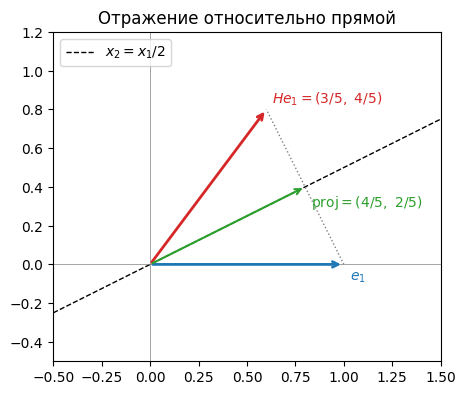

In [9]:
# картинка к упражнению (б)
fig, ax = plt.subplots()
t = np.linspace(-0.5, 1.5, 2)
ax.plot(t, t / 2, "k--", lw=1, label=r"$x_2 = x_1/2$")

refl = H @ e1
ax.annotate("", xy=e1, xytext=(0, 0), arrowprops=dict(color="tab:blue", arrowstyle="->", lw=2))
ax.annotate("", xy=refl, xytext=(0, 0), arrowprops=dict(color="tab:red", arrowstyle="->", lw=2))
ax.annotate("", xy=proj, xytext=(0, 0), arrowprops=dict(color="tab:green", arrowstyle="->", lw=1.5))
ax.plot(*zip(e1, refl), color="gray", lw=1, ls=":")

ax.annotate(r"$e_1$", e1 + [0.03, -0.08], color="tab:blue")
ax.annotate(r"$He_1 = (3/5,\ 4/5)$", refl + [0.03, 0.03], color="tab:red")
ax.annotate(r"$\mathrm{proj} = (4/5,\ 2/5)$", proj + [0.03, -0.1], color="tab:green")

ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.2); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.legend(loc="upper left"); ax.set_title("Отражение относительно прямой")
plt.show()

### Матрица Хаусхолдера

В лекции появляется и вторая формула:

$$A = H(v) = I - 2\,\frac{v v^\top}{v^\top v}.$$

Обратите внимание: это **не та же самая** матрица, что $2\,\frac{vv^\top}{v^\top v} - I$, а её минус. Обе — отражения, но относительно разных объектов:

- $2\,\frac{vv^\top}{v^\top v} - I$ отражает **относительно прямой** $\mathrm{span}(v)$: вектор $v$ остаётся на месте;
- $I - 2\,\frac{vv^\top}{v^\top v}$ отражает **относительно гиперплоскости, перпендикулярной $v$**: теперь $Av = -v$, а всё, что ортогонально $v$, остаётся на месте ($Ar = r$).

Именно вторая (Хаусхолдер) используется в QR. Проверим её свойства: $Av = -v$, $Ar = r$ при $r \perp v$, $A^\top = A$, $A^\top A = I$.

In [10]:
def householder(v):
    v = np.asarray(v, dtype=float)
    return np.eye(len(v)) - 2 * np.outer(v, v) / (v @ v)

v = np.array([2., 1.])
Hv = householder(v)
r = np.array([-1., 2.])                    # r ортогонален v

print("H(v) @ v =", Hv @ v, " (= -v)")
print("H(v) @ r =", Hv @ r, " (= r)")
print("симметрична:", np.allclose(Hv, Hv.T),
      " ортогональна:", np.allclose(Hv.T @ Hv, np.eye(2)),
      " инволюция:", np.allclose(Hv @ Hv, np.eye(2)))

H(v) @ v = [-2. -1.]  (= -v)
H(v) @ r = [-1.  2.]  (= r)
симметрична: True  ортогональна: True  инволюция: True


### Зачем это надо: «завалить вектор на ось»

Подобрав хорошее $v$, можно отразить любой $x$ прямо на ось: $Hx = (\|x\|, 0, \dots, 0)^\top$. Рецепт: $v = x - \|x\|\, e_1$ (отражаем относительно «биссектрисной» гиперплоскости между $x$ и осью).

In [11]:
x = np.array([3., 2., 1., 1.])
v = x - np.linalg.norm(x) * np.eye(len(x))[0]
print("H(v) @ x =", householder(v) @ x)
print("||x||    =", np.linalg.norm(x))

H(v) @ x = [3.873 0.    0.    0.   ]
||x||    = 3.872983346207417


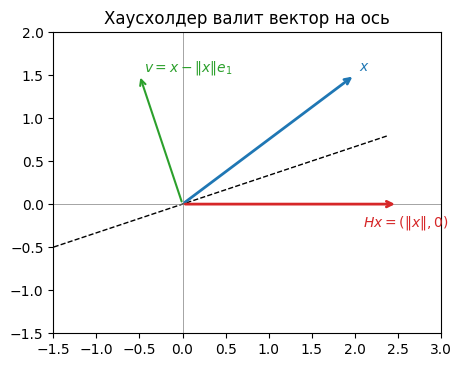

In [12]:
# та же идея в 2D, с картинкой
x2d = np.array([2., 1.5])
v2d = x2d - np.linalg.norm(x2d) * np.array([1., 0.])
Hx = householder(v2d) @ x2d

fig, ax = plt.subplots()
ax.annotate("", xy=x2d, xytext=(0, 0), arrowprops=dict(color="tab:blue", arrowstyle="->", lw=2))
ax.annotate("", xy=Hx, xytext=(0, 0), arrowprops=dict(color="tab:red", arrowstyle="->", lw=2))
ax.annotate("", xy=v2d, xytext=(0, 0), arrowprops=dict(color="tab:green", arrowstyle="->", lw=1.5))

# гиперплоскость отражения — прямая, перпендикулярная v
n = v2d / np.linalg.norm(v2d)
perp = np.array([-n[1], n[0]])
t = np.linspace(-2.5, 2.5, 2)
ax.plot(*(np.outer(t, perp).T), "k--", lw=1)

ax.annotate("$x$", x2d + 0.05, color="tab:blue")
ax.annotate(r"$Hx = (\|x\|, 0)$", Hx + [-0.4, -0.25], color="tab:red")
ax.annotate("$v = x - \|x\|e_1$", v2d + [0.05, 0.05], color="tab:green")

ax.set_xlim(-1.5, 3); ax.set_ylim(-1.5, 2); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Хаусхолдер валит вектор на ось")
plt.show()

## 4. QR через отражения Хаусхолдера

$$A = \big[\,a_1 \mid a_2 \mid \dots \mid a_n\,\big] = Q R, \qquad Q \text{ — ортогональная}, \; R \text{ — верхнетреугольная}.$$

Стратегия: подбираем $H_1$, чтобы обнулить первый столбец ниже диагонали; затем $H_2 = \begin{pmatrix} 1 & 0 \\ 0 & \tilde H \end{pmatrix}$ — блочная, чтобы **сохранить уже добытые нули**, — обнуляет второй столбец ниже диагонали; и так далее:

$$H_k \cdots H_2 H_1 A = R \quad\Rightarrow\quad A = \underbrace{H_1 H_2 \cdots H_k}_{Q}\, R$$

(каждая $H$ — симметричная инволюция, поэтому $H^{-1} = H$).

In [13]:
def qr_householder(A, verbose=False):
    A = A.astype(float)
    m, n = A.shape
    R = A.copy()
    Q = np.eye(m)
    for k in range(min(n, m - 1)):
        col = R[k:, k]
        v = col - np.linalg.norm(col) * np.eye(len(col))[0]
        if np.allclose(v, 0):
            continue
        Hk = np.eye(m)
        Hk[k:, k:] = householder(v)         # блочная структура сохраняет нули
        R = Hk @ R
        Q = Q @ Hk                           # Q = H1 @ H2 @ ... @ Hk
        if verbose:
            print(f"после H{k + 1}:\n{np.round(R, 3) + 0.}\n")
    return Q, R

rng = np.random.default_rng(3)
A = rng.integers(-4, 5, size=(4, 3)).astype(float)
print("A =\n", A, "\n")
Q, R = qr_householder(A, verbose=True)

A =
 [[ 3. -4. -3.]
 [-2. -3.  3.]
 [ 3.  1. -4.]
 [-4. -2. -1.]] 

после H1:
[[ 6.164  0.811 -3.731]
 [ 0.     0.041  2.538]
 [ 0.    -3.561 -3.307]
 [ 0.     4.082 -1.924]]

после H2:
[[ 6.164  0.811 -3.731]
 [ 0.     5.417  0.743]
 [ 0.     0.    -4.496]
 [ 0.     0.    -0.562]]

после H3:
[[ 6.164  0.811 -3.731]
 [ 0.     5.417  0.743]
 [ 0.     0.     4.531]
 [ 0.     0.     0.   ]]



In [14]:
print("Q @ R = A:", np.allclose(Q @ R, A))
print("Q ортогональна:", np.allclose(Q.T @ Q, np.eye(4)))
print("R верхнетреугольная:", np.allclose(R, np.triu(R)))

Q @ R = A: True
Q ортогональна: True
R верхнетреугольная: True


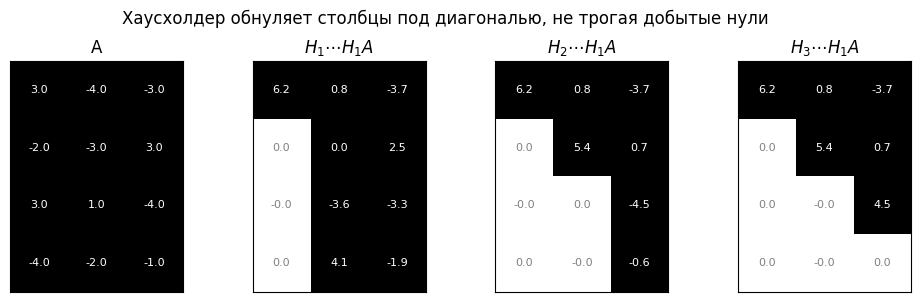

In [15]:
# как «зажигаются» нули: паттерн разреженности после каждого шага
def sparsity_steps(A):
    A = A.astype(float)
    m, n = A.shape
    R = A.copy()
    steps = [R.copy()]
    for k in range(min(n, m - 1)):
        col = R[k:, k]
        v = col - np.linalg.norm(col) * np.eye(len(col))[0]
        Hk = np.eye(m)
        Hk[k:, k:] = householder(v)
        R = Hk @ R
        steps.append(R.copy())
    return steps

steps = sparsity_steps(A)
fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
for ax, S, title in zip(axes, steps, ["A"] + [f"$H_{k}\cdots H_1 A$" for k in range(1, len(steps))]):
    ax.matshow(np.abs(S) > 1e-10, cmap="Greys", vmin=0, vmax=1)
    for (i, j), val in np.ndenumerate(S):
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                color="white" if abs(val) > 1e-10 else "gray", fontsize=8)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Хаусхолдер обнуляет столбцы под диагональю, не трогая добытые нули", y=1.05)
plt.show()

## 5. Вращения Гивенса

Вращение Гивенса $G_{ij}(\varphi)$ — единичная матрица $I_n$, кроме подматрицы $2 \times 2$ на пересечении строк/столбцов $i, j$:

$$G_{ij}(\varphi)\big[[i,j],[i,j]\big] = \begin{pmatrix} \cos\varphi & \sin\varphi \\ -\sin\varphi & \cos\varphi \end{pmatrix}$$

— поворот **по часовой стрелке** в плоскости координат $(i, j)$, остальные координаты не трогает.

Почему матрица именно такая: столбцы — это образы базисных векторов. При повороте по часовой на $\varphi$: $e_1 \mapsto (\cos\varphi, -\sin\varphi)$, $e_2 \mapsto (\sin\varphi, \cos\varphi)$. Матрица ортогональна: $G^{-1}$ — это поворот на $-\varphi$, и он же равен $G^\top$.

In [16]:
def givens(n, i, j, phi):
    G = np.eye(n)
    c, s = np.cos(phi), np.sin(phi)
    G[i, i], G[i, j] = c, s
    G[j, i], G[j, j] = -s, c
    return G

phi = np.pi / 4
G = givens(2, 0, 1, phi)
print("G =\n", G)
print("G.T @ G = I:", np.allclose(G.T @ G, np.eye(2)))
print("G^{-1} = G(-phi):", np.allclose(np.linalg.inv(G), givens(2, 0, 1, -phi)))

G =
 [[ 0.707  0.707]
 [-0.707  0.707]]
G.T @ G = I: True
G^{-1} = G(-phi): True


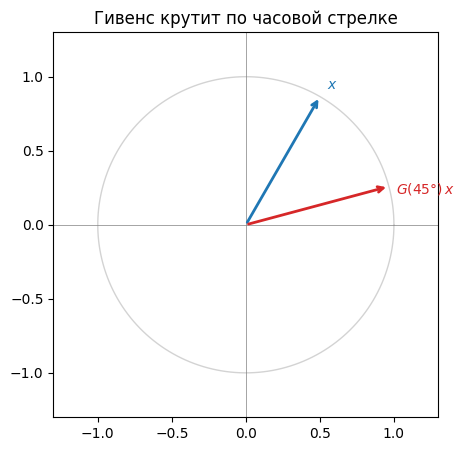

In [17]:
# картинка: поворот по часовой стрелке на единичной окружности
fig, ax = plt.subplots()
t = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(t), np.sin(t), color="lightgray", lw=1)

x0 = np.array([np.cos(np.pi / 3), np.sin(np.pi / 3)])
x1 = G @ x0
ax.annotate("", xy=x0, xytext=(0, 0), arrowprops=dict(color="tab:blue", arrowstyle="->", lw=2))
ax.annotate("", xy=x1, xytext=(0, 0), arrowprops=dict(color="tab:red", arrowstyle="->", lw=2))
ax.annotate("$x$", x0 + 0.05, color="tab:blue")
ax.annotate(r"$G(45°)\,x$", x1 + [0.05, -0.05], color="tab:red")

ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Гивенс крутит по часовой стрелке")
plt.show()

### Повернуть вектор так, чтобы он упал на ось

Применим $G_{13}(\varphi)$ к $(x, y, z)$:

$$\begin{cases} \cos\varphi \cdot x + \sin\varphi \cdot z = x' \\ y = y' \\ -\sin\varphi \cdot x + \cos\varphi \cdot z = z' \end{cases}$$

Хотим $z' = 0$: из $-\sin\varphi \cdot x + \cos\varphi \cdot z = 0$ получаем

$$\cos\varphi = \frac{x}{\sqrt{x^2 + z^2}}, \qquad \sin\varphi = \frac{z}{\sqrt{x^2 + z^2}},$$

и тогда $x' = \sqrt{x^2 + z^2}$ — вся длина «переливается» в первую координату.

In [18]:
x_, z_ = 3., 4.
n = np.hypot(x_, z_)
G = np.array([[x_ / n, z_ / n],
              [-z_ / n, x_ / n]])
print("G @ (3, 4) =", G @ [x_, z_])   # (5, 0): вся длина упала на первую ось

G @ (3, 4) = [ 5. -0.]


### А можно ли одним поворотом обнулить обе координаты?

Соблазн есть: запишем оба желания как систему,

$$\begin{cases} x\cos\varphi + z\sin\varphi = 0 \\ z\cos\varphi - x\sin\varphi = 0 \end{cases}
\qquad\Longleftrightarrow\qquad
\begin{pmatrix} x & z \\ z & -x \end{pmatrix} \begin{pmatrix} \cos\varphi \\ \sin\varphi \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}.$$

Это линейная система относительно $(\cos\varphi, \sin\varphi)$, и она честно «решается»! Но её определитель равен $-(x^2 + z^2) \ne 0$ для ненулевого вектора, поэтому решение единственно: $\cos\varphi = \sin\varphi = 0$. А такого угла **не существует** — нарушено $\cos^2\varphi + \sin^2\varphi = 1$. Вот где прячется подвох: система разрешима как линейная, но её решение не является углом.

Геометрически то же самое видно сразу: поворот сохраняет длину, $x'^2 + z'^2 = x^2 + z^2$, поэтому ненулевой вектор не может перейти в $(0, 0)$. Каждое уравнение **по отдельности** решается — свой угол находится и для $x' = 0$, и для $z' = 0$, — но эти углы всегда разные (отличаются ровно на $90°$).

In [ ]:
x_, z_ = 3., 4.
M = np.array([[x_, z_],
              [z_, -x_]])

print("det =", np.linalg.det(M))
sol = np.linalg.solve(M, [0., 0.])
print("решение системы (cos, sin) =", sol, " -> cos^2 + sin^2 =", sol @ sol, ", а нужно 1")

det = -25.000000000000007
решение системы (cos, sin) = [0. 0.]  -> cos^2 + sin^2 = 0.0 , а нужно 1


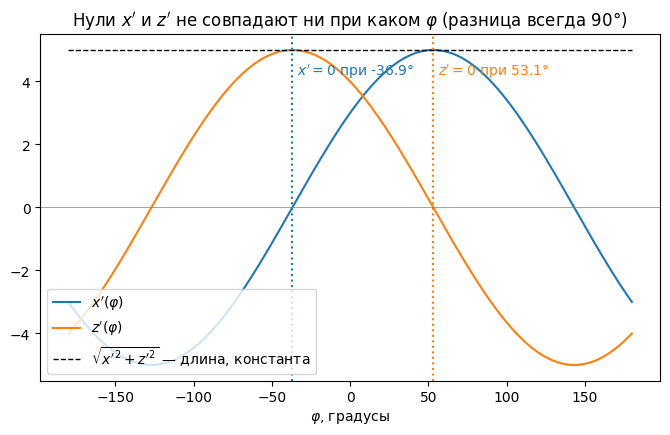

угол между нулями: 90.0 градусов


In [20]:
# развёртка по углу: каждую координату обнулить можно, но при разных phi
phis = np.linspace(-np.pi, np.pi, 721)
xp = np.cos(phis) * x_ + np.sin(phis) * z_
zp = -np.sin(phis) * x_ + np.cos(phis) * z_

phi_z0 = np.arctan2(z_, x_)     # здесь z' = 0 (вектор падает на ось x)
phi_x0 = np.arctan2(-x_, z_)    # здесь x' = 0 (вектор падает на ось z)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(phis), xp, label="$x'(\\varphi)$")
ax.plot(np.degrees(phis), zp, label="$z'(\\varphi)$")
ax.plot(np.degrees(phis), np.hypot(xp, zp), "k--", lw=1,
        label="$\\sqrt{x'^2 + z'^2}$ — длина, константа")
ax.axhline(0, color="gray", lw=0.5)
for phi0, lbl, clr in [(phi_z0, "$z'=0$", "tab:orange"), (phi_x0, "$x'=0$", "tab:blue")]:
    ax.axvline(np.degrees(phi0), color=clr, ls=":", lw=1.5)
    ax.annotate(f"{lbl} при {np.degrees(phi0):.1f}°", (np.degrees(phi0) + 3, 4.2), color=clr)
ax.set_xlabel("$\\varphi$, градусы"); ax.legend(loc="lower left")
ax.set_title("Нули $x'$ и $z'$ не совпадают ни при каком $\\varphi$ (разница всегда 90°)")
plt.show()

print("угол между нулями:", np.degrees(phi_z0 - phi_x0), "градусов")

In [21]:
# пример из лекции: (1/sqrt(2), 3, 1/sqrt(2)), G13 с углом 45°
vec = np.array([1 / np.sqrt(2), 3., 1 / np.sqrt(2)])
x_, z_ = vec[0], vec[2]
phi = np.arctan2(z_, x_)
print("phi =", np.degrees(phi), "градусов")
print("G13(phi) @ vec =", givens(3, 0, 2, phi) @ vec)   # ожидаем (1, 3, 0)

phi = 45.0 градусов
G13(phi) @ vec = [1. 3. 0.]


### Повороты в 3D: роняем вектор на ось за два шага

Каждый поворот Гивенса крутит ровно одну координатную плоскость, остальные координаты заморожены. Поэтому в $\mathbb{R}^3$ вектор укладывается на ось $x$ за два хода:

1. $G_{13}$ крутит плоскость $(x, z)$ — координата $y$ не шевелится — и обнуляет $z$: получаем $\left(\sqrt{x^2 + z^2},\ y,\ 0\right)$;
2. $G_{12}$ крутит плоскость $(x, y)$ — а $z$ уже нулевой и таким остаётся — и обнуляет $y$: получаем $\left(\|v\|,\ 0,\ 0\right)$.

Длина при каждом шаге сохраняется, так что в конце вся она собирается в первой координате. В $\mathbb{R}^n$ так же: $n - 1$ поворотов укладывают любой вектор на ось — ровно это Гивенс делает с первым столбцом матрицы в QR.

In [22]:
v0 = np.array([1 / np.sqrt(2), 3., 1 / np.sqrt(2)])   # тот же вектор из лекции

phi1 = np.arctan2(v0[2], v0[0])          # G13: обнуляем z
v1 = givens(3, 0, 2, phi1) @ v0
phi2 = np.arctan2(v1[1], v1[0])          # G12: обнуляем y
v2 = givens(3, 0, 1, phi2) @ v1

print("v  =", v0, "  ||v|| =", np.linalg.norm(v0))
print("G13 @ v       =", v1)
print("G12 @ G13 @ v =", v2)

v  = [0.707 3.    0.707]   ||v|| = 3.1622776601683795
G13 @ v       = [1. 3. 0.]
G12 @ G13 @ v = [3.162 0.    0.   ]


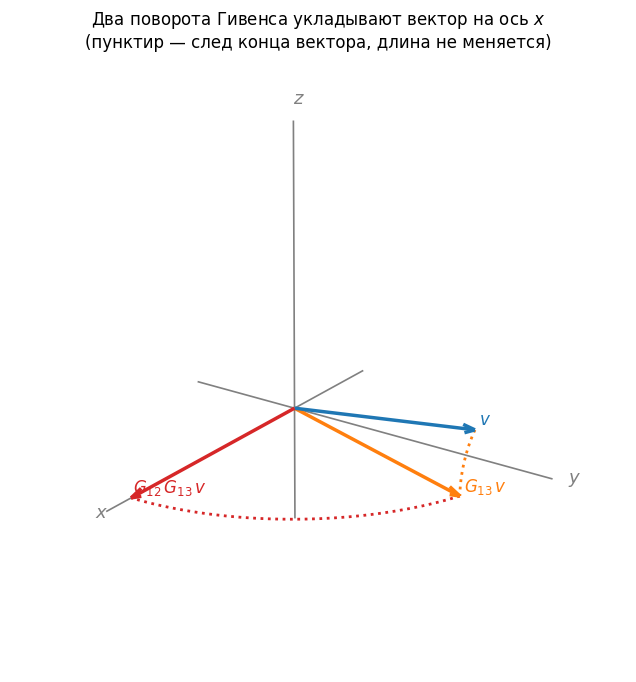

In [23]:
# дуги, которые заметает конец вектора во время каждого поворота
t = np.linspace(0, 1, 80)
arc1 = np.array([givens(3, 0, 2, phi1 * s) @ v0 for s in t])   # в плоскости y = 3
arc2 = np.array([givens(3, 0, 1, phi2 * s) @ v1 for s in t])   # в плоскости z = 0

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")

L = 3.6
for axis, name in zip(np.eye(3), ["$x$", "$y$", "$z$"]):
    ax.plot(*zip(-0.4 * L * axis, L * axis), color="gray", lw=1.2)
    ax.text(*(L * axis * 1.06), name, color="gray", fontsize=13)

for v, c, lbl in [(v0, "tab:blue", "$v$"),
                  (v1, "tab:orange", "$G_{13}\,v$"),
                  (v2, "tab:red", "$G_{12}\,G_{13}\,v$")]:
    ax.quiver(0, 0, 0, *v, color=c, lw=2.5, arrow_length_ratio=0.06)
    ax.text(*(v + 0.15), lbl, color=c, fontsize=12)

ax.plot(*arc1.T, color="tab:orange", ls=":", lw=2)
ax.plot(*arc2.T, color="tab:red", ls=":", lw=2)

ax.set_box_aspect((1, 1, 1))
ax.set_xlim(-0.5, L); ax.set_ylim(-0.5, L); ax.set_zlim(-0.5, L)
ax.view_init(elev=22, azim=35)
ax.set_axis_off()   # свои оси уже нарисованы - штатная коробка только шумит
ax.set_title("Два поворота Гивенса укладывают вектор на ось $x$\n"
             "(пунктир — след конца вектора, длина не меняется)")
plt.show()

## 6. QR через повороты Гивенса

Та же стратегия, что и с отражениями, только нули добываем по одному: $G_{ij}$ обнуляет элемент $(j, i)$, крутя строки $i$ и $j$. Порядок — по столбцам слева направо, снизу вверх.

In [24]:
def qr_givens(A):
    A = A.astype(float)
    m, n = A.shape
    R = A.copy()
    Q = np.eye(m)
    for j in range(n):
        for i in range(m - 1, j, -1):
            if abs(R[i, j]) < 1e-14:
                continue
            phi = np.arctan2(R[i, j], R[j, j])
            G = givens(m, j, i, phi)
            R = G @ R
            Q = Q @ G.T
    return Q, R

Qg, Rg = qr_givens(A)
print("R (Гивенс) =\n", Rg)
print("\nQ @ R = A:", np.allclose(Qg @ Rg, A))
print("Q ортогональна:", np.allclose(Qg.T @ Qg, np.eye(4)))

R (Гивенс) =
 [[ 6.164  0.811 -3.731]
 [-0.     5.417  0.743]
 [ 0.     0.     4.531]
 [ 0.    -0.     0.   ]]

Q @ R = A: True
Q ортогональна: True


In [25]:
# сверка трёх способов: Хаусхолдер, Гивенс, np.linalg.qr
Q_np, R_np = np.linalg.qr(A)

# QR единственно с точностью до знаков строк R (и столбцов Q) —
# приведём все R к положительной диагонали и сравним
def fix_signs(Q, R):
    s = np.sign(np.diag(R))
    s[s == 0] = 1
    k = len(s)
    return Q[:, :k] * s, s[:, None] * R[:k]

for name, (Qi, Ri) in {"Хаусхолдер": (Q, R), "Гивенс": (Qg, Rg),
                        "np.linalg.qr": (Q_np, R_np)}.items():
    Qf, Rf = fix_signs(Qi, Ri)
    print(f"{name:>14}: R =\n{Rf}\n")

    Хаусхолдер: R =
[[ 6.164  0.811 -3.731]
 [ 0.     5.417  0.743]
 [ 0.    -0.     4.531]]

        Гивенс: R =
[[ 6.164  0.811 -3.731]
 [-0.     5.417  0.743]
 [ 0.     0.     4.531]]

  np.linalg.qr: R =
[[ 6.164  0.811 -3.731]
 [ 0.     5.417  0.743]
 [ 0.     0.     4.531]]



## 7. Гивенс vs Хаусхолдер

Оба инструмента ортогонально добывают нули, но с разной гранулярностью:

| | Хаусхолдер | Гивенс |
|---|---|---|
| Один шаг | отражение $H_k$ | поворот $G_{ij}(\varphi)$ |
| Нулей за шаг | весь столбец под диагональю | ровно один |
| Трогает | весь хвост матрицы | две строки |
| Хорош для | плотных матриц (так устроен `np.linalg.qr` / LAPACK) | разреженных и почти треугольных; дешёвых обновлений готового QR |

На плотной матрице выигрывает Хаусхолдер: шагов меньше, суммарных операций тоже (у Гивенса флопов примерно в полтора раза больше). Но когда нулей и так много, Гивенс бьёт точечно — только по реальным ненулям, а Хаусхолдер всё равно ворочает целые блоки.

In [26]:
# на плотной матрице m x n: Хаусхолдеру нужно min(n, m-1) отражений,
# Гивенсу — по повороту на каждый поддиагональный элемент
m, n_ = 6, 4
print("Хаусхолдер:", min(n_, m - 1), "отражения")
print("Гивенс:    ", sum(m - 1 - j for j in range(n_)), "поворотов")

Хаусхолдер: 4 отражения
Гивенс:     14 поворотов


## Итоги

- Матричные разложения переписывают «непонятную» матрицу через произведение «понятных»: треугольных, ортогональных, диагональных.
- Ортогональные матрицы сохраняют длины, расстояния и углы, их произведение снова ортогонально — поэтому из них удобно собирать $Q$.
- Отражение Хаусхолдера $H(v) = I - 2\frac{vv^\top}{v^\top v}$ одним махом валит вектор на ось: так добываем нули под диагональю сразу столбцами.
- Вращение Гивенса $G_{ij}(\varphi)$ крутит одну координатную плоскость и обнуляет элементы по одному; для обнуления $z'$ берём $\cos\varphi = \frac{x}{\sqrt{x^2+z^2}}$, $\sin\varphi = \frac{z}{\sqrt{x^2+z^2}}$. Обнулить одним поворотом обе координаты нельзя: формальное решение системы $\cos\varphi = \sin\varphi = 0$ углом не является, а геометрически поворот сохраняет длину.
- Оба пути дают $A = QR$ и сходятся с `np.linalg.qr` с точностью до знаков.
- На плотных матрицах выгоднее Хаусхолдер, на разреженных и почти треугольных — Гивенс: он трогает только две строки на поворот и пропускает готовые нули.